# Day 5 — Tuning, Evaluation & Sprint Review

## Heart Disease Prediction

Today we will continue directly from the Day 4 Heart Disease neural network.

The goal is to:
- Tune the neural network systematically, changing one hyperparameter at a time.
- Compare validation performance across experiments.
- Use EarlyStopping to stop training when validation loss stops improving.
- Use ModelCheckpoint to save the best model.
- Evaluate the final tuned model on the unseen test set.
- Assemble evidence for the Sprint 1 Review.
- Complete the Sprint 1 Retrospective.
##  Starting Point from Day 4

In Day 4, we built two neural networks for the `HeartDiseaseorAttack` binary classification task:

- A baseline neural network.
- A regularized neural network using Batch Normalization and Dropout.

The regularized architecture from Day 4 is our starting point for today's tuning experiments. The train, validation, and test sets, together with the scaled features, are already prepared above.

**Important:** The test set will not be used for hyperparameter tuning. We use the validation set to choose the best configuration and reserve the test set for the final evaluation.


### Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
print(tf.__version__)
print(tf.config.list_physical_devices())

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


##  Load and Inspect the Dataset

We will continue using the same Heart Disease dataset from the Phase 3 project.
The target variable is `HeartDiseaseorAttack`, which represents whether the patient has heart disease or has experienced a heart attack.
Since this is a binary classification problem, the target contains two classes:

- `0` → No heart disease/heart attack
- `1` → Heart disease/heart attack

In [3]:
df=pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["HeartDiseaseorAttack"].value_counts())

Dataset shape: (253680, 22)

Target distribution:
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64


## Define Features and Target
We separate the dataset into:
- `X`: input features used by the neural network.
- `y`: target variable that the model is trying to predict.
The target column is removed from `X` because the model should not use the answer itself as an input feature.

In [4]:
X = df.drop("HeartDiseaseorAttack", axis=1)
y = df["HeartDiseaseorAttack"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (253680, 21)
Target shape: (253680,)


### Train, Validation, and Test Sets
We divide the data into three parts:
#### Training Set
Used to learn the model's weights.
#### Validation Set
Used during training to monitor how well the model generalizes to unseen data.
#### Test Set
Used only at the end to obtain the final unbiased evaluation.
The test set must remain unseen during training.
We will use a stratified split so that the proportion of the two classes remains approximately similar across the datasets.

In [5]:
# First split: training + validation vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
# Second split: training vs validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val,test_size=0.20,random_state=42,stratify=y_train_val)
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (162355, 21)
Validation set: (40589, 21)
Test set: (50736, 21)


## 5. Feature Scaling

Neural networks generally perform better when numerical features are on comparable scales.
We use `StandardScaler` to transform the features so that they have approximately:
- Mean = 0
- Standard deviation = 1
The scaler is fitted only on the training data to avoid data leakage.
The same transformation is then applied to the validation and test sets.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[-0.86722707 -0.85772556  0.19675625 -1.11703401  1.12237805 -0.20532932
  -0.42620967  0.56664549  0.75808143  0.48175749 -0.24403074  0.22837637
  -0.30315444 -0.47820148 -0.42928575  0.31547182 -0.44933238 -0.88627011
  -0.01222021  0.96401029  0.4563055 ]
 [ 1.15310053  1.16587408  0.19675625 -0.20992868 -0.89096539 -0.20532932
  -0.42620967  0.56664549  0.75808143  0.48175749 -0.24403074  0.22837637
  -0.30315444  0.4571784  -0.42928575 -0.48697267 -0.44933238  1.12832419
  -0.33961484 -0.05203678 -0.50915912]
 [-0.86722707 -0.85772556  0.19675625 -0.20992868 -0.89096539 -0.20532932
  -0.42620967  0.56664549  0.75808143  0.48175749 -0.24403074  0.22837637
  -0.30315444 -0.47820148 -0.42928575 -0.48697267 -0.44933238 -0.88627011
   1.62475296 -1.06808385 -1.47462373]
 [-0.86722707 -0.85772556  0.19675625 -0.81466557  1.12237805 -0.20532932
  -0.42620967  0.56664549 -1.31911951 -2.07573318 -0.24403074  0.22837637
  -0.30315444 -1.41358135 -0.42928575 -0

### Determine the Number of Input Features

The number of input neurons must match the number of features in the dataset.
For example, if the dataset contains 20 input features, the input layer receives 20 values for every sample.

In [7]:
n_features = X_train_scaled.shape[1]
print("Number of input features:", n_features)

Number of input features: 21


### Build the Baseline Neural Network
We now build our first neural network using the Keras Sequential API.
The architecture contains:
- Input layer with `n_features` inputs.
- Hidden layer with 64 neurons and ReLU activation.
- Hidden layer with 32 neurons and ReLU activation.
- Output layer with one neuron and Sigmoid activation.
#### Why ReLU?
ReLU is commonly used in hidden layers because it introduces non-linearity and helps neural networks learn complex patterns.
#### Why Sigmoid?
This is a binary classification problem. Sigmoid converts the output into a value between 0 and 1, which can be interpreted as the probability of the positive class.

In [8]:
baseline_model = Sequential([Dense(64, activation="relu", input_shape=(n_features,)),Dense(32, activation="relu"),Dense(1, activation="sigmoid")])
baseline_model.summary()

c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the Baseline Model
Before training, the model must be compiled.
We specify:
#### Optimizer: Adam
Adam updates the model's weights during training. It is widely used because it adapts the learning rate for each parameter.
#### Loss: Binary Crossentropy
Binary crossentropy is appropriate for binary classification problems with a sigmoid output.
#### Metric: Accuracy
Accuracy measures the proportion of predictions that are correct.

In [10]:
baseline_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

### Train the Baseline Neural Network
The `fit()` method starts the training process.
An epoch represents one complete pass through the training data.
We use:
- `epochs=30`
- `batch_size=32`
- Validation data to monitor performance on unseen validation samples.
The returned `history` object stores the loss and accuracy for both training and validation after every epoch.

In [11]:
history_baseline = baseline_model.fit(X_train_scaled,y_train,validation_data=(X_val_scaled, y_val),epochs=30,batch_size=32,verbose=1)

Epoch 1/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9069 - loss: 0.2428 - val_accuracy: 0.9078 - val_loss: 0.2379
Epoch 2/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9085 - loss: 0.2373 - val_accuracy: 0.9069 - val_loss: 0.2377
Epoch 3/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9083 - loss: 0.2363 - val_accuracy: 0.9075 - val_loss: 0.2380
Epoch 4/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9087 - loss: 0.2357 - val_accuracy: 0.9075 - val_loss: 0.2374
Epoch 5/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9090 - loss: 0.2351 - val_accuracy: 0.9072 - val_loss: 0.2383
Epoch 6/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9089 - loss: 0.2348 - val_accuracy: 0.9075 - val_loss: 0.2374
Epoch 7/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9091 - loss: 0.2343 - val_accuracy: 0.9068 - val_loss: 0.2389
Epoch 8/30
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9090 - loss: 0

### Evaluate the Baseline Model on the Test Set
The test set was not used during training.
Therefore, evaluating on the test set provides an estimate of how well the trained neural network generalizes to completely unseen data.

In [12]:
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_scaled,y_test,verbose=0)
print("Baseline Test Loss:", baseline_test_loss)
print("Baseline Test Accuracy:", baseline_test_accuracy)

Baseline Test Loss: 0.24544237554073334
Baseline Test Accuracy: 0.9039735198020935


In [13]:
# Day 4 starting configuration
base_learning_rate = 0.001
base_neurons = 64
base_dropout = 0.30
base_batch_size = 32

print("Starting configuration:")
print("Learning rate:", base_learning_rate)
print("Neurons:", base_neurons)
print("Dropout:", base_dropout)
print("Batch size:", base_batch_size)


Starting configuration:
Learning rate: 0.001
Neurons: 64
Dropout: 0.3
Batch size: 32


##  Create a Tunable Model

We keep the same basic architecture used in Day 4:

`Dense(64) → BatchNormalization → Dropout → Dense(32) → Dropout → Sigmoid`

The function below allows us to change one hyperparameter at a time while keeping the others fixed.

This makes the experiments easier to compare and follows the tuning strategy required for this day.


In [14]:
from tensorflow.keras import Input

def build_tunable_model(
    learning_rate=0.001,
    neurons=64,
    dropout_rate=0.30
):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(neurons, activation="relu"),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(32, activation="relu"),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


##  Tuning Strategy

We will change one variable at a time.

The order is:

1. Learning rate
2. Network width (number of neurons)
3. Dropout rate
4. Batch size

For every experiment, we record:
- The changed hyperparameter.
- The best validation loss.
- The best validation accuracy.

The validation results are used for model selection. The test set remains untouched during this stage.


In [15]:
TUNING_EPOCHS = 10

experiment_results = []

def run_experiment(name, learning_rate, neurons, dropout_rate, batch_size):
    model = build_tunable_model(
        learning_rate=learning_rate,
        neurons=neurons,
        dropout_rate=dropout_rate
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=TUNING_EPOCHS,
        batch_size=batch_size,
        verbose=0
    )

    best_val_loss = min(history.history["val_loss"])
    best_val_accuracy = max(history.history["val_accuracy"])

    experiment_results.append({
        "Experiment": name,
        "Learning Rate": learning_rate,
        "Neurons": neurons,
        "Dropout": dropout_rate,
        "Batch Size": batch_size,
        "Best Validation Loss": best_val_loss,
        "Best Validation Accuracy": best_val_accuracy
    })

    return history


###  Tune Learning Rate

Learning rate controls how large the weight updates are during optimization.

We test three values while keeping network size, dropout, and batch size fixed.


In [16]:
learning_rate_values = [0.0001, 0.001, 0.01]

for lr in learning_rate_values:
    run_experiment(
        name=f"Learning Rate = {lr}",
        learning_rate=lr,
        neurons=base_neurons,
        dropout_rate=base_dropout,
        batch_size=base_batch_size
    )

learning_rate_results = pd.DataFrame(experiment_results)
learning_rate_results


,Experiment,Learning Rate,Neurons,Dropout,Batch Size,Best Validation Loss,Best Validation Accuracy
0,Learning Rate = 0.0001,0.0001,64,0.3,32,0.237595,0.907734
1,Learning Rate = 0.001,0.0010,64,0.3,32,0.236444,0.908079
2,Learning Rate = 0.01,0.0100,64,0.3,32,0.237625,0.907955


###  Tune Network Width

Next, we change only the number of neurons in the first hidden layer.

A wider layer can learn more complex patterns, but an unnecessarily large network can increase the risk of overfitting.


In [17]:
for neurons in [32, 64, 128]:
    run_experiment(
        name=f"Neurons = {neurons}",
        learning_rate=base_learning_rate,
        neurons=neurons,
        dropout_rate=base_dropout,
        batch_size=base_batch_size
    )

network_results = pd.DataFrame(experiment_results).tail(3)
network_results


,Experiment,Learning Rate,Neurons,Dropout,Batch Size,Best Validation Loss,Best Validation Accuracy
3,Neurons = 32,0.001,32,0.3,32,0.236608,0.908005
4,Neurons = 64,0.001,64,0.3,32,0.236573,0.908005
5,Neurons = 128,0.001,128,0.3,32,0.236350,0.908005


###  Tune Dropout

Dropout is a regularization technique that randomly disables a fraction of neurons during training.

We change only the dropout rate and keep the other settings at their starting values.


In [18]:
for dropout in [0.10, 0.30, 0.50]:
    run_experiment(
        name=f"Dropout = {dropout}",
        learning_rate=base_learning_rate,
        neurons=base_neurons,
        dropout_rate=dropout,
        batch_size=base_batch_size
    )

dropout_results = pd.DataFrame(experiment_results).tail(3)
dropout_results


,Experiment,Learning Rate,Neurons,Dropout,Batch Size,Best Validation Loss,Best Validation Accuracy
6,Dropout = 0.1,0.001,64,0.1,32,0.236603,0.908325
7,Dropout = 0.3,0.001,64,0.3,32,0.236651,0.907783
8,Dropout = 0.5,0.001,64,0.5,32,0.237031,0.908005


###  Tune Batch Size

Batch size determines how many training samples are processed before the model updates its weights.

We test three batch sizes while keeping the other settings fixed.


In [19]:
for batch_size in [16, 32, 64]:
    run_experiment(
        name=f"Batch Size = {batch_size}",
        learning_rate=base_learning_rate,
        neurons=base_neurons,
        dropout_rate=base_dropout,
        batch_size=batch_size
    )

batch_results = pd.DataFrame(experiment_results).tail(3)
batch_results


,Experiment,Learning Rate,Neurons,Dropout,Batch Size,Best Validation Loss,Best Validation Accuracy
9,Batch Size = 16,0.001,64,0.3,16,0.236475,0.907906
10,Batch Size = 32,0.001,64,0.3,32,0.236130,0.908054
11,Batch Size = 64,0.001,64,0.3,64,0.236250,0.907955


##  Compare All Tuning Experiments
The table below collects every tuning run.
A lower validation loss is generally better because it means the model's predictions are closer to the correct targets according to the binary crossentropy loss.


In [20]:
all_results = pd.DataFrame(experiment_results)

all_results = all_results.sort_values(
    by="Best Validation Loss"
).reset_index(drop=True)

all_results


,Experiment,Learning Rate,Neurons,Dropout,Batch Size,Best Validation Loss,Best Validation Accuracy
0,Batch Size = 32,0.0010,64,0.3,32,0.236130,0.908054
1,Batch Size = 64,0.0010,64,0.3,64,0.236250,0.907955
2,Neurons = 128,0.0010,128,0.3,32,0.236350,0.908005
3,Learning Rate = 0.001,0.0010,64,0.3,32,0.236444,0.908079
4,Batch Size = 16,0.0010,64,0.3,16,0.236475,0.907906
5,Neurons = 64,0.0010,64,0.3,32,0.236573,0.908005
6,Dropout = 0.1,0.0010,64,0.1,32,0.236603,0.908325
7,Neurons = 32,0.0010,32,0.3,32,0.236608,0.908005
8,Dropout = 0.3,0.0010,64,0.3,32,0.236651,0.907783
9,Dropout = 0.5,0.0010,64,0.5,32,0.237031,0.908005


In [21]:
best_overall_experiment = all_results.iloc[0]

print("Best validation-loss experiment:")
print(best_overall_experiment)


Best validation-loss experiment:
Experiment                  Batch Size = 32
Learning Rate                         0.001
Neurons                                  64
Dropout                                 0.3
Batch Size                               32
Best Validation Loss                0.23613
Best Validation Accuracy           0.908054
Name: 0, dtype: object


##  Select the Best Value for Each Hyperparameter
Because we changed one variable at a time, we can select the best validation result from each group
These values will be combined into the final tuned configuration.
The test set is still not used here.


In [22]:
best_lr_row = learning_rate_results.loc[
    learning_rate_results["Best Validation Loss"].idxmin()
]

best_neurons_row = network_results.loc[
    network_results["Best Validation Loss"].idxmin()
]

best_dropout_row = dropout_results.loc[
    dropout_results["Best Validation Loss"].idxmin()
]

best_batch_row = batch_results.loc[
    batch_results["Best Validation Loss"].idxmin()
]

best_learning_rate = best_lr_row["Learning Rate"]
best_neurons = int(best_neurons_row["Neurons"])
best_dropout = best_dropout_row["Dropout"]
best_batch_size = int(best_batch_row["Batch Size"])

print("Selected configuration:")
print("Learning rate:", best_learning_rate)
print("Neurons:", best_neurons)
print("Dropout:", best_dropout)
print("Batch size:", best_batch_size)


Selected configuration:
Learning rate: 0.001
Neurons: 128
Dropout: 0.1
Batch size: 32


##  Train the Final Tuned Network with EarlyStopping
Now we train a fresh model using the selected configuration.
We allow up to 100 epochs, but `EarlyStopping` can stop training earlier if validation loss stops improving.
`restore_best_weights=True` restores the weights from the best validation-loss epoch.


In [23]:
final_model = build_tunable_model(
    learning_rate=best_learning_rate,
    neurons=best_neurons,
    dropout_rate=best_dropout
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[early_stopping],
    verbose=1
)

print("Epochs actually trained:", len(final_history.history["loss"]))


Epoch 1/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9053 - loss: 0.2502 - val_accuracy: 0.9065 - val_loss: 0.2419
Epoch 2/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9071 - loss: 0.2417 - val_accuracy: 0.9073 - val_loss: 0.2380
Epoch 3/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9074 - loss: 0.2403 - val_accuracy: 0.9072 - val_loss: 0.2388
Epoch 4/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9075 - loss: 0.2395 - val_accuracy: 0.9073 - val_loss: 0.2373
Epoch 5/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9077 - loss: 0.2392 - val_accuracy: 0.9074 - val_loss: 0.2368
Epoch 6/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9076 - loss: 0.2387 - val_accuracy: 0.9086 - val_loss: 0.2367
Epoch 7/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9080 - loss: 0.2382 - val_accuracy: 0.9080 - val_loss: 0.2370
Epoch 8/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9078 -

### Why EarlyStopping?

EarlyStopping monitors `val_loss`.

If the validation loss does not improve for the chosen patience period, training stops automatically.

This helps:
- Avoid unnecessary epochs.
- Reduce the risk of overfitting.
- Save training time.

With `restore_best_weights=True`, the final model keeps the weights from the best validation-loss epoch rather than simply using the last epoch.


##  Save the Best Model with ModelCheckpoint

`ModelCheckpoint` saves the best model observed during training.

This is different from EarlyStopping:

- **EarlyStopping** decides when training should stop.
- **ModelCheckpoint** saves the best version of the model.


In [24]:
checkpoint_path = "best_heart_disease_day5.keras"

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True
)

checkpoint_model = build_tunable_model(
    learning_rate=best_learning_rate,
    neurons=best_neurons,
    dropout_rate=best_dropout
)

checkpoint_history = checkpoint_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=best_batch_size,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

print("Best model saved to:", checkpoint_path)
print("Epochs actually trained:", len(checkpoint_history.history["loss"]))


Epoch 1/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9034 - loss: 0.2543 - val_accuracy: 0.9075 - val_loss: 0.2384
Epoch 2/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9074 - loss: 0.2421 - val_accuracy: 0.9066 - val_loss: 0.2382
Epoch 3/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9076 - loss: 0.2400 - val_accuracy: 0.9075 - val_loss: 0.2380
Epoch 4/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9079 - loss: 0.2394 - val_accuracy: 0.9066 - val_loss: 0.2381
Epoch 5/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9075 - loss: 0.2392 - val_accuracy: 0.9074 - val_loss: 0.2378
Epoch 6/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9076 - loss: 0.2387 - val_accuracy: 0.9076 - val_loss: 0.2371
Epoch 7/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9080 - loss: 0.2385 - val_accuracy: 0.9075 - val_loss: 0.2366
Epoch 8/100
5074/5074 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9081 -

##  Final Evaluation on the Unseen Test Set
Only now do we use the test set.
The test set was not used during tuning, so this gives us the final estimate of how well the tuned network generalizes to unseen data.


In [25]:
final_test_loss, final_test_accuracy = checkpoint_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Final Tuned Test Loss:", final_test_loss)
print("Final Tuned Test Accuracy:", final_test_accuracy)


Final Tuned Test Loss: 0.23758651316165924
Final Tuned Test Accuracy: 0.907481849193573


##  Detailed Classification Metrics

Accuracy alone does not tell the complete story, especially because the target classes are imbalanced.

We therefore also report precision, recall, and F1-score.


In [26]:
y_prob_final = checkpoint_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

y_pred_final = (y_prob_final >= 0.5).astype(int)

final_report = classification_report(
    y_test,
    y_pred_final,
    target_names=["No Heart Disease", "Heart Disease"],
    output_dict=True
)

print(classification_report(
    y_test,
    y_pred_final,
    target_names=["No Heart Disease", "Heart Disease"]
))


                  precision    recall  f1-score   support

No Heart Disease       0.92      0.99      0.95     45957
   Heart Disease       0.54      0.12      0.20      4779

        accuracy                           0.91     50736
       macro avg       0.73      0.56      0.58     50736
    weighted avg       0.88      0.91      0.88     50736



In [27]:
final_precision = final_report["weighted avg"]["precision"]
final_recall = final_report["weighted avg"]["recall"]
final_f1 = final_report["weighted avg"]["f1-score"]

print("Final Accuracy :", final_test_accuracy)
print("Final Precision:", final_precision)
print("Final Recall   :", final_recall)
print("Final F1-score :", final_f1)


Final Accuracy : 0.907481849193573
Final Precision: 0.8800881303538297
Final Recall   : 0.907481866918953
Final F1-score : 0.8801532649451352


##  Final Loss Curve

This curve is part of the evidence for the Sprint Review.

We look at training loss and validation loss to understand the learning behavior of the final tuned network.


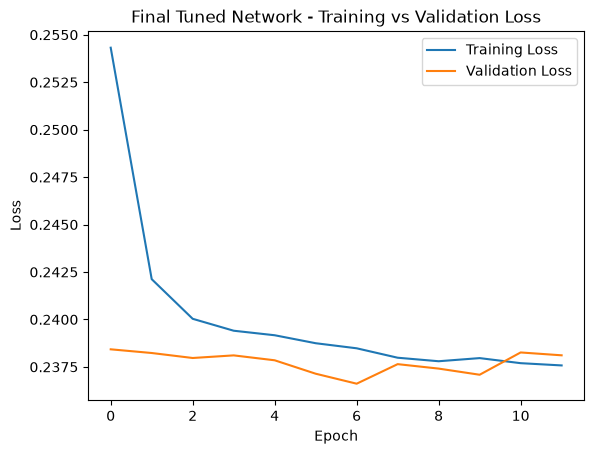

In [28]:
plt.plot(
    checkpoint_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    checkpoint_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Tuned Network - Training vs Validation Loss")
plt.legend()
plt.show()


##  Final Accuracy Curve


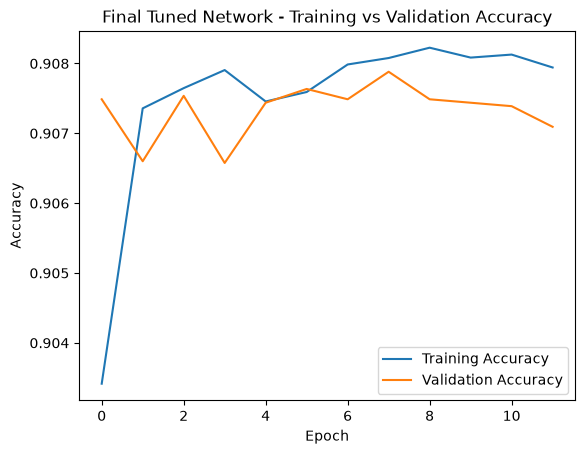

In [29]:

plt.plot(
    checkpoint_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    checkpoint_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Tuned Network - Training vs Validation Accuracy")
plt.legend()
plt.show()


##  Sprint 1 Metric Comparison

We compare:
- Day 1 baseline accuracy.
- Day 4 baseline neural network.
- Day 4 regularized neural network.
- Day 5 tuned neural network.

This gives clear evidence of how the model developed during Sprint 1.


In [35]:
day1_baseline_accuracy = 0.745023

sprint_comparison = pd.DataFrame({
    "Model": [
        "Day 1 Baseline",
        "Day 4 Baseline Neural Network",
        "Day 5 Tuned Neural Network"
    ],
    "Test Accuracy": [
        day1_baseline_accuracy,
        baseline_test_accuracy,
        final_test_accuracy
    ]
})

sprint_comparison

,Model,Test Accuracy
0,Day 1 Baseline,0.745023
1,Day 4 Baseline Neural Network,0.903974
2,Day 5 Tuned Neural Network,0.907482


##  Final Model Configuration

The final configuration selected from the validation experiments is:


In [31]:
final_configuration = pd.DataFrame({
    "Hyperparameter": [
        "Learning Rate",
        "First Hidden Layer Neurons",
        "Dropout Rate",
        "Batch Size",
        "Maximum Epochs",
        "EarlyStopping Patience"
    ],
    "Value": [
        best_learning_rate,
        best_neurons,
        best_dropout,
        best_batch_size,
        100,
        5
    ]
})

final_configuration


,Hyperparameter,Value
0,Learning Rate,0.001
1,First Hidden Layer Neurons,128.000
2,Dropout Rate,0.100
3,Batch Size,32.000
4,Maximum Epochs,100.000
5,EarlyStopping Patience,5.000


In [32]:
checkpoint_model.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,957 (85.77 KB)

 Trainable params: 7,233 (28.25 KB)

 Non-trainable params: 256 (1.00 KB)

 Optimizer params: 14,468 (56.52 KB)

##  Sprint 1 Evidence Checklist

The following evidence is now available in this notebook:

- Baseline neural network performance.
- Regularized neural network performance.
- One-variable-at-a-time tuning experiments.
- Validation loss and validation accuracy for the experiments.
- EarlyStopping.
- ModelCheckpoint.
- Final tuned model configuration.
- Final test metrics.
- Final loss and accuracy curves.
- Baseline versus tuned model comparison.


##  Sprint 1 Acceptance Criteria

Before closing Sprint 1, verify the following:

- [x] The notebook runs without errors.
- [x] Hyperparameters were tuned one variable at a time.
- [x] Validation results were recorded for every experiment.
- [x] EarlyStopping was implemented.
- [x] ModelCheckpoint was implemented.
- [x] The best model was saved.
- [x] The final model was evaluated on the unseen test set.
- [x] Baseline and tuned metrics were compared.
- [x] Loss curves were included.
- [x] Results were documented in Markdown.
- [x] All Sprint 1 work is committed to the correct branch.
- [x] The Pull Request is approved/merged after mentor review.


### Sprint Review

#### What was completed?

During Sprint 1, a neural network was developed for the Heart Disease Prediction task.

The initial network was improved using Batch Normalization and Dropout. In Day 5, the network was tuned systematically by changing one hyperparameter at a time: learning rate, network width, dropout rate, and batch size.

EarlyStopping was used to stop training when validation loss stopped improving, while ModelCheckpoint saved the best model.

The final tuned model was evaluated on the unseen test set and compared with the earlier baseline models.


### Sprint 1 Retrospective

#### What went well?

- Built and trained a complete neural network using Keras.
- Used validation data to guide model tuning.
- Tested the main high-impact hyperparameters systematically.
- Added EarlyStopping and ModelCheckpoint.
- Documented model performance and compared it with the baseline.

#### What could be improved?

- Experiment configurations and results could be tracked more systematically.
- Future experiments could be organized in a dedicated experiment log.
- Hyperparameter interactions could be investigated after the one-variable-at-a-time tuning stage.

#### One Concrete Change for Sprint 2

For Sprint 2, every experiment will be recorded with its configuration, validation result, and final evaluation so that model changes can be compared more clearly.


## Final Conclusion

The Sprint 1 Heart Disease Prediction neural network was tuned systematically using validation data.

The final model used the selected learning rate, network width, dropout rate, and batch size. EarlyStopping helped prevent unnecessary training, and ModelCheckpoint preserved the best model.

The final test-set metrics, loss curves, and comparison table provide the evidence needed for the Sprint 1 Review.
